# 53 - SNP directos en bloques (Notebook friendly)

Version derivada para uso interactivo en notebook: ejecucion separada por algoritmo (una celda por modelo).

## 1) Configuracion global

In [13]:
from pathlib import Path
import re
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.stats import pearsonr

from sklearn.base import clone
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold, ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# =========================
# Rutas
# =========================
RAW_PATH = Path("merged_all_mind0.20_g0.10_mac1_nomaf_pruned_raw.raw")
PHENO_PATH = Path("pheno_data/BLUEs_across_env.tsv")
META_PATH = Path("pheno_data/giae121_supplemental_file.xlsx")
META_HEADER_ROW = 2

OUTPUT_DIR = Path("results/snp_blocks_notebook_nested5x3")
RIDGE_OUT = OUTPUT_DIR / "ridge_results.csv"
ELASTICNET_OUT = OUTPUT_DIR / "elasticnet_results.csv"
XGBOOST_OUT = OUTPUT_DIR / "xgboost_results.csv"
ALL_OUT = OUTPUT_DIR / "all_results.csv"
BEST_GLOBAL_OUT = OUTPUT_DIR / "best_global_results.csv"

# =========================
# Flags de ejecucion
# =========================
RUN_RIDGE = True
RUN_ELASTICNET = True
RUN_XGBOOST = True

# =========================
# Validacion cruzada (Nested CV 5x3)
# =========================
N_SPLITS = 5          # outer folds
N_INNER_SPLITS = 3    # inner folds
RANDOM_STATE = 42
PRINT_EVERY_FOLD = False

# =========================
# Control y logging
# =========================
TOP_N_MISSING = 10
STOP_ON_MODEL_ERROR = False

# =========================
# Traits
# =========================
TRAITS_CANDIDATOS = [
    "lodging",
    "plant_height",
    "blumeria_graminis",
    "heading_date",
    "puccinia_hordei",
    "ramularia_collo_cygni",
    "rhynchosporium",
]

# =========================
# Grids
# =========================
PARAM_GRIDS = {
    "ridge": {
        "alpha": [0.1, 1.0, 10.0, 100.0, 300.0, 1000.0],
    },
    "elasticnet": {
        "alpha": [0.01, 0.1, 1.0, 10.0],
        "l1_ratio": [0.05, 0.1, 0.3, 0.5],
    },
    "xgboost": {
        "n_estimators": [400],
        "learning_rate": [0.05],
        "max_depth": [3, 5],
        "subsample": [0.7],
        "colsample_bytree": [0.1, 0.3],
        "reg_lambda": [1.0, 5.0],
    },
}

# =========================
# Import robusto de XGBoost
# =========================
try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except Exception as exc:
    XGBRegressor = None
    XGBOOST_AVAILABLE = False
    XGBOOST_IMPORT_ERROR = str(exc)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"OUTPUT_DIR: {OUTPUT_DIR}")
print(f"XGBOOST_AVAILABLE: {XGBOOST_AVAILABLE}")
if not XGBOOST_AVAILABLE:
    print("XGBoost no esta disponible. El bloque XGBoost se omitira.")


OUTPUT_DIR: results\snp_blocks_notebook_nested5x3
XGBOOST_AVAILABLE: True


### Selección de hiperparámetros en modelos de predicción genómica (SNPs directos)

La definición de los espacios de búsqueda de hiperparámetros se realizó considerando las características específicas del problema: alta dimensionalidad (p >> n), fuerte correlación entre marcadores (LD), y naturaleza mayoritariamente aditiva de los efectos genéticos.

---

#### Ridge Regression

Se evaluaron distintos valores del parámetro de regularización:

- `alpha`: [0.1, 1.0, 10.0, 100.0]

**Justificación:**
- Ridge es el baseline estándar en predicción genómica (equivalente a GBLUP).
- Penaliza coeficientes sin eliminarlos, lo que es coherente con rasgos poligénicos.
- El rango de `alpha` permite explorar desde baja regularización (modelo más flexible) hasta alta regularización (modelo más estable).
- No se amplió el grid ya que Ridge mostró comportamiento robusto y consistente.

---

#### Elastic Net

Se evaluó una combinación de regularización L1 y L2:

- `alpha`: [0.01, 0.1, 1.0]  
- `l1_ratio`: [0.05, 0.1, 0.3]

**Justificación:**
- Permite introducir sparsity (selección de variables) en un contexto de alta dimensionalidad.
- Se priorizaron valores bajos de `l1_ratio` para mantener un comportamiento cercano a Ridge, evitando eliminar en exceso SNPs correlacionados (debido al LD).
- Valores altos de L1 no se consideraron adecuados, ya que pueden descartar marcadores relevantes en regiones ligadas.
- El grid es deliberadamente reducido para evitar problemas de convergencia y alto coste computacional observados en fases preliminares.

---

#### XGBoost (Gradient Boosting Trees)

Se evaluaron configuraciones conservadoras orientadas a evitar sobreajuste:

- `n_estimators`: [400, 600]  
- `learning_rate`: [0.05]  
- `max_depth`: [3, 5]  
- `subsample`: [0.7]  
- `colsample_bytree`: [0.1, 0.3]  
- `reg_lambda`: [1.0]

**Justificación:**
- `learning_rate` bajo (0.05) permite un aprendizaje progresivo y estable.
- `n_estimators` se incrementa para compensar el bajo learning rate y evaluar si el modelo sigue captando señal.
- `max_depth` limitado (3–5) restringe la complejidad y controla la aparición de interacciones espurias.
- `subsample < 1` introduce aleatoriedad y mejora la generalización.
- `colsample_bytree` bajo es especialmente relevante en contextos con muchos SNPs, forzando al modelo a explorar diferentes subconjuntos de marcadores y reduciendo redundancia por LD.
- `reg_lambda` se fija tras observar un impacto limitado en fases previas, evitando expandir innecesariamente el espacio de búsqueda.

El grid se ha reducido respecto a iteraciones iniciales, priorizando eficiencia computacional y capacidad interpretativa. La evidencia empírica sugiere que, en este contexto, modelos más complejos no aportan mejoras sustanciales frente a enfoques lineales.

---

#### Estrategia general

- Se emplea validación cruzada (`KFold`) con una única repetición (`n_repeats = 1`) en esta fase, priorizando exploración eficiente del espacio de modelos.
- La repetición de CV se reserva para fases posteriores de validación final.
- Se evita una búsqueda exhaustiva de hiperparámetros en esta etapa, dado que el objetivo principal es identificar familias de modelos relevantes más que optimizar al máximo cada configuración.

---

## 2) Instalacion opcional de XGBoost (manual)

In [2]:
# OPCIONAL. No se ejecuta automaticamente.
# Descomenta solo si necesitas instalar xgboost en tu entorno.

# %pip install xgboost
# %pip install xgboost-cpu
# !mamba install -c conda-forge py-xgboost -y

print("Celda opcional de instalacion. No instala nada si no descomentas.")


Celda opcional de instalacion. No instala nada si no descomentas.


## 3) Carga del .raw y preparacion inicial SNP

In [3]:
if not RAW_PATH.exists():
    raise FileNotFoundError(f"No se encuentra el archivo .raw: {RAW_PATH}")

raw = pd.read_csv(RAW_PATH, sep=r"\s+")

print(f"RAW path: {RAW_PATH}")
print(f"raw shape: {raw.shape}")
print("primeras columnas:", raw.columns[:15].tolist())

META_COLS_BASE = ["FID", "IID", "PAT", "MAT", "SEX", "PHENOTYPE"]
meta_cols_present = [c for c in META_COLS_BASE if c in raw.columns]
print("meta cols detectadas:", meta_cols_present)

if "IID" not in raw.columns:
    raise KeyError("La columna IID no existe en el .raw.")

ids = raw["IID"].astype(str).str.strip().rename("IID")
snp_cols = [c for c in raw.columns if c not in META_COLS_BASE]
X_snp = raw[snp_cols].copy()

print(f"SNP matrix: {X_snp.shape}")
print(f"IID unicos: {ids.nunique()} / {len(ids)}")

if ids.duplicated().any():
    raise ValueError("Hay IID duplicados en el .raw. Resolver antes de modelar.")


RAW path: merged_all_mind0.20_g0.10_mac1_nomaf_pruned_raw.raw
raw shape: (1110, 61145)
primeras columnas: ['FID', 'IID', 'PAT', 'MAT', 'SEX', 'PHENOTYPE', 'chr1H_81414_C_T_C', 'chr1H_131970_G_A_G', 'chr1H_674995_T_C_T', 'chr1H_715339_C_T_C', 'chr1H_725342_C_T_C', 'chr1H_745354_T_C_T', 'chr1H_755359_G_T_G', 'chr1H_765367_G_A_G', 'chr1H_775376_G_A_G']
meta cols detectadas: ['FID', 'IID', 'PAT', 'MAT', 'SEX', 'PHENOTYPE']
SNP matrix: (1110, 61139)
IID unicos: 1110 / 1110


## 4) Auditoria basica de SNPs

In [4]:
n_ind, n_snp = X_snp.shape

missing_total = int(X_snp.isna().sum().sum())
missing_prop_global = missing_total / (n_ind * n_snp)

missing_por_snp = X_snp.isna().mean().sort_values(ascending=False)
missing_por_ind = X_snp.isna().mean(axis=1)

print(f"Dimensiones SNP (n x p): {n_ind} x {n_snp}")
print(f"Missing total: {missing_total}")
print(f"Missing global: {missing_prop_global:.4%}")

print("\nTop SNPs con mas missing:")
display(missing_por_snp.head(TOP_N_MISSING).to_frame("missing_rate"))

print("\nTop individuos con mas missing:")
display(
    pd.DataFrame({"IID": ids.values, "missing_rate": missing_por_ind.values})
    .sort_values("missing_rate", ascending=False)
    .head(TOP_N_MISSING)
)


Dimensiones SNP (n x p): 1110 x 61139
Missing total: 1072129
Missing global: 1.5798%

Top SNPs con mas missing:


,missing_rate
chr1H_4419119_T_C_T,0.1
chr7H_347493323_G_A_G,0.1
chr7H_282428120_G_A_G,0.1
chr4H_534605866_C_T_C,0.1
chr5H_285512264_T_C_T,0.1
chr3H_121454488_C_A_C,0.1
chr4H_137126353_C_G_C,0.1
chr4H_188329277_T_A_T,0.1
chr4H_131703570_G_A_G,0.1
chr4H_549311969_G_A_G,0.1



Top individuos con mas missing:


,IID,missing_rate
971,SAMEA110189115,0.067731
968,SAMEA110189114,0.066717
840,SAMEA110189695,0.062971
1106,SAMEA110189428,0.061205
913,SAMEA110189336,0.061139
908,SAMEA110189616,0.058751
911,SAMEA110189335,0.058719
941,SAMEA110189502,0.058555
1105,SAMEA110189426,0.058032
970,SAMEA110189043,0.057443


## 5) Merge fenotipico y construccion de model_df

In [5]:
if not PHENO_PATH.exists():
    raise FileNotFoundError(f"No se encuentra archivo fenotipico: {PHENO_PATH}")
if not META_PATH.exists():
    raise FileNotFoundError(f"No se encuentra metadata: {META_PATH}")

na_vals = ["", "NA", "NaN", "na", "N/A", "null", "NULL"]
df_pheno = pd.read_csv(PHENO_PATH, sep="\t", na_values=na_vals)
meta = pd.read_excel(META_PATH, header=META_HEADER_ROW)
meta = meta.loc[:, ~meta.columns.astype(str).str.contains(r"^Unnamed", regex=True)].copy()

print(f"df_pheno shape: {df_pheno.shape}")
print(f"meta shape: {meta.shape}")

if "genotypes" not in df_pheno.columns:
    raise KeyError("En fenotipo no existe la columna 'genotypes'.")

# IID en metadata
iid_candidates = ["IID", "BioSamples ID", "BioSample ID", "biosamples id", "sample_id", "Sample_ID"]
rename_map = {}
for c in iid_candidates:
    if c in meta.columns:
        rename_map[c] = "IID"
        break
meta = meta.rename(columns=rename_map)
if "IID" not in meta.columns:
    raise KeyError("No se encontro columna IID en metadata.")


def norm_name(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip().upper()
    x = re.sub(r"[^A-Z0-9]+", "", x)
    return x if x else np.nan

meta["IID"] = meta["IID"].astype(str).str.strip()
df_pheno["genotypes"] = df_pheno["genotypes"].astype(str).str.strip()
df_pheno["GENO_NORM"] = df_pheno["genotypes"].apply(norm_name)

candidate_name_cols = ["genotype", "genotype name used for BioSamples", "Genebank name"]
meta_name_cols = [c for c in candidate_name_cols if c in meta.columns]
if not meta_name_cols:
    raise KeyError("No hay columnas utiles para construir puente genotipo -> IID.")

bridge_parts = []
for col in meta_name_cols:
    tmp = meta[["IID", col]].copy().rename(columns={col: "GENO_RAW"})
    bridge_parts.append(tmp)

bridge_df = pd.concat(bridge_parts, ignore_index=True)
bridge_df["GENO_NORM"] = bridge_df["GENO_RAW"].apply(norm_name)
bridge_df = bridge_df.dropna(subset=["IID", "GENO_NORM"]).drop_duplicates(["IID", "GENO_NORM"])

# Mantener SOLO traits fenotipicos
pheno_trait_cols = [t for t in TRAITS_CANDIDATOS if t in df_pheno.columns]
if not pheno_trait_cols:
    raise ValueError("Ningun trait candidato existe en df_pheno.")

for t in pheno_trait_cols:
    df_pheno[t] = pd.to_numeric(df_pheno[t], errors="coerce")

pheno_unique = (
    df_pheno.dropna(subset=["GENO_NORM"])
    .groupby("GENO_NORM", as_index=False)[pheno_trait_cols]
    .mean()
)

iid_pheno = bridge_df[["IID", "GENO_NORM"]].merge(pheno_unique, on="GENO_NORM", how="left")
iid_pheno = iid_pheno.drop_duplicates(subset=["IID"])
iid_pheno = iid_pheno[["IID"] + pheno_trait_cols].copy()

# merge final
snp_df = pd.concat([ids, X_snp], axis=1)
model_df = snp_df.merge(iid_pheno, on="IID", how="left")

feature_cols = snp_cols.copy()
traits_disponibles = [t for t in TRAITS_CANDIDATOS if t in model_df.columns]

print("Columnas puente usadas:", meta_name_cols)
print("Traits disponibles:", traits_disponibles)
print(f"model_df shape: {model_df.shape}")


df_pheno shape: (1197, 12)
meta shape: (1110, 15)
Columnas puente usadas: ['genotype', 'genotype name used for BioSamples', 'Genebank name']
Traits disponibles: ['lodging', 'plant_height', 'blumeria_graminis', 'heading_date', 'puccinia_hordei', 'ramularia_collo_cygni', 'rhynchosporium']
model_df shape: (1110, 61147)


## 6) Checks obligatorios previos

In [6]:
# 6.1 Estructura de columnas
if "feature_cols" not in globals():
    raise NameError("feature_cols no existe.")

if "IID" not in model_df.columns:
    raise KeyError("IID no esta presente en model_df.")

feature_set = set(feature_cols)
snp_set = set(snp_cols)
if feature_set != snp_set:
    raise ValueError("feature_cols no coincide exactamente con las columnas SNP.")

traits_in_features = [t for t in traits_disponibles if t in feature_cols]
if traits_in_features:
    raise ValueError(f"Hay traits dentro de feature_cols: {traits_in_features}")

non_snp_cols = [c for c in model_df.columns if c not in feature_cols]
extra_cols = [c for c in non_snp_cols if c not in ["IID"] + traits_disponibles]

print("[CHECK] Estructura")
print(f"Numero columnas SNP: {len(feature_cols)}")
print(f"Numero columnas no SNP: {len(non_snp_cols)}")
print(f"Columnas extra: {extra_cols}")
if extra_cols:
    raise ValueError("Hay columnas inesperadas en model_df.")

# 6.2 Tipos en SNPs
non_numeric_features = [c for c in feature_cols if not pd.api.types.is_numeric_dtype(model_df[c])]
if non_numeric_features:
    raise TypeError(f"Hay features SNP no numericos. Ejemplo: {non_numeric_features[:10]}")

# 6.3 Missing en X
X_full = model_df[feature_cols]
missing_total_X = int(X_full.isna().sum().sum())
missing_prop_X = missing_total_X / (X_full.shape[0] * X_full.shape[1])
missing_by_snp = X_full.isna().mean().sort_values(ascending=False)
missing_by_ind = X_full.isna().mean(axis=1)

print("\n[CHECK] Missing en X")
print(f"Missing total en X: {missing_total_X}")
print(f"Missing global en X: {missing_prop_X:.4%}")
print("Top SNP missing:")
display(missing_by_snp.head(TOP_N_MISSING).to_frame("missing_rate"))
print("Top individuo missing:")
display(
    pd.DataFrame({"IID": model_df["IID"], "missing_rate": missing_by_ind})
    .sort_values("missing_rate", ascending=False)
    .head(TOP_N_MISSING)
)

# Nota importante:
# Puede haber NaN en la matriz original de SNPs.
# Todos los pipelines incluyen imputacion (SimpleImputer),
# por lo que ningun modelo debe entrenar con missing sin tratar.
print("Confirmacion: todos los pipelines usan SimpleImputer(strategy='mean').")

# 6.4 Resumen por trait
trait_checks = []
for trait in traits_disponibles:
    y = pd.to_numeric(model_df[trait], errors="coerce")
    mask = y.notna()
    X_sub = X_full.loc[mask]
    y_sub = y.loc[mask]

    if y_sub.isna().any():
        raise ValueError(f"Trait={trait}: y conserva NaN tras limpieza.")
    if len(X_sub) != len(y_sub):
        raise ValueError(f"Trait={trait}: X e y no tienen la misma longitud.")
    if len(y_sub) < N_SPLITS:
        raise ValueError(f"Trait={trait}: muestras insuficientes para CV (n={len(y_sub)}, n_splits={N_SPLITS}).")
    if np.nanstd(y_sub.values) == 0:
        raise ValueError(f"Trait={trait}: varianza nula en y.")

    trait_checks.append({
        "trait": trait,
        "n_valid": int(len(y_sub)),
        "y_has_nan_after_clean": bool(y_sub.isna().any()),
        "x_y_same_len": bool(len(X_sub) == len(y_sub)),
        "y_std": float(np.nanstd(y_sub.values)),
    })

trait_checks_df = pd.DataFrame(trait_checks)
print("\n[CHECK] Resumen por trait")
display(trait_checks_df)

print("Todos los checks obligatorios pasaron.")


[CHECK] Estructura
Numero columnas SNP: 61139
Numero columnas no SNP: 8
Columnas extra: []

[CHECK] Missing en X
Missing total en X: 1072129
Missing global en X: 1.5798%
Top SNP missing:


,missing_rate
chr1H_4419119_T_C_T,0.1
chr7H_347493323_G_A_G,0.1
chr7H_282428120_G_A_G,0.1
chr4H_534605866_C_T_C,0.1
chr5H_285512264_T_C_T,0.1
chr3H_121454488_C_A_C,0.1
chr4H_137126353_C_G_C,0.1
chr4H_188329277_T_A_T,0.1
chr4H_131703570_G_A_G,0.1
chr4H_549311969_G_A_G,0.1


Top individuo missing:


,IID,missing_rate
971,SAMEA110189115,0.067731
968,SAMEA110189114,0.066717
840,SAMEA110189695,0.062971
1106,SAMEA110189428,0.061205
913,SAMEA110189336,0.061139
908,SAMEA110189616,0.058751
911,SAMEA110189335,0.058719
941,SAMEA110189502,0.058555
1105,SAMEA110189426,0.058032
970,SAMEA110189043,0.057443


Confirmacion: todos los pipelines usan SimpleImputer(strategy='mean').

[CHECK] Resumen por trait


,trait,n_valid,y_has_nan_after_clean,x_y_same_len,y_std
0,lodging,1110,False,True,1.582876
1,plant_height,1110,False,True,14.331034
2,blumeria_graminis,1110,False,True,1.163945
3,heading_date,1110,False,True,31.776664
4,puccinia_hordei,1110,False,True,1.188641
5,ramularia_collo_cygni,1110,False,True,1.121002
6,rhynchosporium,1110,False,True,0.915272


Todos los checks obligatorios pasaron.


In [7]:
model_df.sample(5)

,IID,chr1H_81414_C_T_C,chr1H_131970_G_A_G,chr1H_674995_T_C_T,chr1H_715339_C_T_C,chr1H_725342_C_T_C,chr1H_745354_T_C_T,chr1H_755359_G_T_G,chr1H_765367_G_A_G,chr1H_775376_G_A_G,...,chr7H_631979650_A_C_A,chr7H_632100414_G_A_G,chr7H_632170572_C_A_C,lodging,plant_height,blumeria_graminis,heading_date,puccinia_hordei,ramularia_collo_cygni,rhynchosporium
693,SAMEA110189296,0.0,2.0,2.0,2.0,2.0,0.0,2.0,2.0,2.0,...,2.0,2.0,2.0,5.712273,94.305560,3.725854,73.392989,5.010516,4.443297,1.348300
853,SAMEA110189639,0.0,2.0,2.0,2.0,2.0,0.0,0.0,0.0,2.0,...,2.0,NaN,2.0,4.099073,131.009309,4.607817,134.935597,4.391929,5.281835,4.077338
286,SAMEA110189979,0.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,...,2.0,2.0,2.0,1.931993,93.929804,3.014089,134.738161,3.736892,4.369808,1.331034
288,SAMEA110189927,2.0,2.0,2.0,2.0,2.0,2.0,0.0,2.0,2.0,...,2.0,2.0,2.0,1.109247,96.660339,2.572181,138.761545,3.042942,3.608224,2.286672
956,SAMEA110189023,0.0,2.0,2.0,2.0,2.0,2.0,0.0,2.0,2.0,...,2.0,2.0,2.0,1.938721,111.453805,5.290949,137.567537,4.056999,4.654388,1.653217


## 7) Funciones auxiliares comunes

In [14]:
def print_block_header(name):
    print("=" * 80)
    print(f"INICIO BLOQUE: {name.upper()}")
    print("=" * 80)


def print_block_footer(name, elapsed_s, cfg_executed, fits_executed):
    print("=" * 80)
    print(f"FIN BLOQUE: {name.upper()}")
    print(f"Tiempo total del bloque: {elapsed_s:.2f} s")
    print(f"Configuraciones ejecutadas: {cfg_executed}")
    print(f"Fits totales: {fits_executed}")
    print("=" * 80)


def build_pipeline(model_name, params):
    model_name = model_name.lower()

    if model_name == "ridge":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="mean")),
            ("scaler", StandardScaler()),
            ("model", Ridge(alpha=params["alpha"], random_state=RANDOM_STATE)),
        ])

    if model_name == "elasticnet":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="mean")),
            ("scaler", StandardScaler()),
            (
                "model",
                ElasticNet(
                    alpha=params["alpha"],
                    l1_ratio=params["l1_ratio"],
                    max_iter=20000,
                    selection="random",
                    random_state=RANDOM_STATE,
                ),
            ),
        ])

    if model_name == "xgboost":
        if not XGBOOST_AVAILABLE:
            raise ImportError("XGBoost no disponible en este entorno.")
        return Pipeline([
            ("imputer", SimpleImputer(strategy="mean")),
            (
                "model",
                XGBRegressor(
                    objective="reg:squarederror",
                    tree_method="hist",
                    random_state=RANDOM_STATE,
                    n_jobs=1,
                    verbosity=0,
                    n_estimators=params["n_estimators"],
                    learning_rate=params["learning_rate"],
                    max_depth=params["max_depth"],
                    subsample=params["subsample"],
                    colsample_bytree=params["colsample_bytree"],
                    reg_lambda=params["reg_lambda"],
                ),
            ),
        ])

    raise ValueError(f"Modelo no soportado: {model_name}")


def prepare_trait_data(model_df, feature_cols, trait):
    y = pd.to_numeric(model_df[trait], errors="coerce")
    mask = y.notna()

    X_trait = model_df.loc[mask, feature_cols]
    y_trait = y.loc[mask].astype(float).values

    if np.isnan(y_trait).any():
        raise ValueError(f"Trait={trait}: y contiene NaN tras limpieza.")
    if X_trait.shape[0] != y_trait.shape[0]:
        raise ValueError(f"Trait={trait}: X e y desalineados.")
    if X_trait.shape[0] < N_SPLITS:
        raise ValueError(f"Trait={trait}: muestras insuficientes para CV.")
    if np.nanstd(y_trait) == 0:
        raise ValueError(f"Trait={trait}: varianza nula en target.")

    return X_trait, y_trait


def nested_oof_predict_manual(model_name, param_grid, X, y, n_outer_splits, n_inner_splits, random_state, print_every_fold=False):
    X_np = X.to_numpy(dtype=float, copy=False)
    y_np = np.asarray(y, dtype=float)

    param_list = list(ParameterGrid(param_grid))
    if not param_list:
        raise ValueError("param_grid sin configuraciones")

    outer_cv = KFold(n_splits=n_outer_splits, shuffle=True, random_state=random_state)

    y_pred = np.full(len(y_np), np.nan, dtype=float)
    best_params_by_fold = []
    fit_count = 0
    t0 = time.perf_counter()

    for fold_idx, (tr_idx, te_idx) in enumerate(outer_cv.split(X_np), start=1):
        X_tr, y_tr = X_np[tr_idx], y_np[tr_idx]
        X_te = X_np[te_idx]

        inner_cv = KFold(n_splits=n_inner_splits, shuffle=True, random_state=random_state + fold_idx)

        best_params = None
        best_score = -np.inf

        for cfg_idx, params in enumerate(param_list, start=1):
            fold_scores = []

            for inner_tr_idx, inner_va_idx in inner_cv.split(X_tr, y_tr):
                est = build_pipeline(model_name, params)
                est.fit(X_tr[inner_tr_idx], y_tr[inner_tr_idx])
                pred_va = est.predict(X_tr[inner_va_idx])
                score = r2_score(y_tr[inner_va_idx], pred_va)
                fold_scores.append(score)
                fit_count += 1

            mean_score = float(np.mean(fold_scores)) if fold_scores else -np.inf
            if mean_score > best_score:
                best_score = mean_score
                best_params = params

            if print_every_fold:
                print(f"    outer_fold={fold_idx}/{n_outer_splits} cfg={cfg_idx}/{len(param_list)} inner_mean_r2={mean_score:.4f}")

        final_est = build_pipeline(model_name, best_params)
        final_est.fit(X_tr, y_tr)
        y_pred[te_idx] = final_est.predict(X_te)
        fit_count += 1

        best_params_by_fold.append(best_params)

    if np.isnan(y_pred).any():
        raise RuntimeError("NaN detectado en predicciones OOF de nested CV.")

    elapsed_s = time.perf_counter() - t0
    return y_pred, fit_count, elapsed_s, best_params_by_fold


def compute_metrics(y_true, y_pred):
    pearson_r, pearson_p = pearsonr(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    r2 = float(r2_score(y_true, y_pred))
    return {
        "pearson_r": float(pearson_r),
        "pearson_p": float(pearson_p),
        "rmse": rmse,
        "r2": r2,
    }


def params_to_str(params):
    return ", ".join([f"{k}={v}" for k, v in params.items()])


def _mode_params(params_list):
    if not params_list:
        return {}
    keys = sorted(params_list[0].keys())
    serial = [tuple((k, p[k]) for k in keys) for p in params_list]
    counts = pd.Series(serial).value_counts()
    top = dict(counts.index[0])
    return top


def run_model_block(
    model_name,
    model_df,
    feature_cols,
    traits_disponibles,
    param_grid,
    n_outer_splits,
    n_inner_splits,
    random_state,
    print_every_fold=False,
    stop_on_model_error=False,
):
    param_list = list(ParameterGrid(param_grid))
    n_cfg = len(param_list)

    print_block_header(model_name)
    print(f"Configuraciones por trait: {n_cfg}")

    block_results = []
    cfg_executed = 0
    fits_executed = 0
    block_t0 = time.perf_counter()

    fits_por_trait = n_outer_splits * (n_cfg * n_inner_splits + 1)

    for trait in traits_disponibles:
        X_trait, y_trait = prepare_trait_data(model_df, feature_cols, trait)

        print("-" * 80)
        print(f"Trait: {trait}")
        print(
            f"n={len(y_trait)} | p={X_trait.shape[1]} | configuraciones={n_cfg} | "
            f"fits esperados nested={fits_por_trait}"
        )

        try:
            y_pred, fit_count, elapsed_s, best_params_by_fold = nested_oof_predict_manual(
                model_name=model_name,
                param_grid=param_grid,
                X=X_trait,
                y=y_trait,
                n_outer_splits=n_outer_splits,
                n_inner_splits=n_inner_splits,
                random_state=random_state,
                print_every_fold=print_every_fold,
            )

            m = compute_metrics(y_trait, y_pred)
            best_mode = _mode_params(best_params_by_fold)

            block_results.append(
                {
                    "model": model_name,
                    "trait": trait,
                    "params": params_to_str(best_mode),
                    "n_individuos": int(len(y_trait)),
                    "n_snps": int(X_trait.shape[1]),
                    "n_configs_model": int(n_cfg),
                    "fits_por_config": int(n_outer_splits * n_inner_splits),
                    "fits_ejecutados_config": int(fit_count),
                    "pearson_r": m["pearson_r"],
                    "pearson_p": m["pearson_p"],
                    "rmse": m["rmse"],
                    "r2": m["r2"],
                    "fit_time_s": float(elapsed_s),
                    "cv": f"NestedKFold_manual(outer={n_outer_splits}, inner={n_inner_splits}, random_state={random_state})",
                }
            )

            cfg_executed += n_cfg
            fits_executed += fit_count

            print(
                f"    -> R2={m['r2']:.4f} | Pearson={m['pearson_r']:.4f} | "
                f"RMSE={m['rmse']:.4f} | fits={fit_count} | t={elapsed_s:.2f}s"
            )

        except Exception as exc:
            msg = f"[ERROR] {model_name} | {trait} -> {exc}"
            if stop_on_model_error:
                raise RuntimeError(msg) from exc
            print(msg)

    elapsed_block = time.perf_counter() - block_t0
    block_df = pd.DataFrame(block_results)

    if not block_df.empty:
        block_df = block_df.sort_values(by=["trait", "r2", "pearson_r"], ascending=[True, False, False]).reset_index(drop=True)
        best_by_trait = (
            block_df
            .sort_values(by=["trait", "r2", "pearson_r"], ascending=[True, False, False])
            .groupby("trait", as_index=False)
            .first()
            .sort_values(by=["r2", "pearson_r"], ascending=[False, False])
            .reset_index(drop=True)
        )
    else:
        best_by_trait = pd.DataFrame()

    print_block_footer(model_name, elapsed_block, cfg_executed, fits_executed)

    block_summary = {
        "model": model_name,
        "run": True,
        "time_s": float(elapsed_block),
        "configs_executed": int(cfg_executed),
        "fits_executed": int(fits_executed),
        "configs_per_trait": int(n_cfg),
        "fits_por_trait": int(fits_por_trait),
    }

    return block_df, best_by_trait, block_summary


## 8) Bloque Ridge (celda independiente)

In [9]:
if RUN_RIDGE:
    resultados_ridge_df, best_ridge_df, summary_ridge = run_model_block(
        model_name="ridge",
        model_df=model_df,
        feature_cols=feature_cols,
        traits_disponibles=traits_disponibles,
        param_grid=PARAM_GRIDS["ridge"],
        n_outer_splits=N_SPLITS,
        n_inner_splits=N_INNER_SPLITS,
        random_state=RANDOM_STATE,
        print_every_fold=PRINT_EVERY_FOLD,
        stop_on_model_error=STOP_ON_MODEL_ERROR,
    )

    if not resultados_ridge_df.empty:
        resultados_ridge_df.to_csv(RIDGE_OUT, index=False)
        print(f"Guardado: {RIDGE_OUT}")
        print("Mejor configuracion por trait (Ridge):")
        display(best_ridge_df)
    else:
        print("Ridge: bloque ejecutado sin resultados.")
else:
    resultados_ridge_df = pd.DataFrame()
    best_ridge_df = pd.DataFrame()
    summary_ridge = {
        "model": "ridge",
        "run": False,
        "time_s": 0.0,
        "configs_executed": 0,
        "fits_executed": 0,
        "configs_per_trait": 0,
        "fits_por_trait": 0,
    }
    print("Bloque Ridge omitido (RUN_RIDGE=False).")


INICIO BLOQUE: RIDGE
Configuraciones por trait: 6
--------------------------------------------------------------------------------
Trait: lodging
n=1110 | p=61139 | configuraciones=6 | fits esperados nested=95
    -> R2=0.7688 | Pearson=0.8774 | RMSE=0.7612 | fits=95 | t=413.53s
--------------------------------------------------------------------------------
Trait: plant_height
n=1110 | p=61139 | configuraciones=6 | fits esperados nested=95
    -> R2=0.6421 | Pearson=0.8026 | RMSE=8.5730 | fits=95 | t=351.26s
--------------------------------------------------------------------------------
Trait: blumeria_graminis
n=1110 | p=61139 | configuraciones=6 | fits esperados nested=95
    -> R2=0.5602 | Pearson=0.7488 | RMSE=0.7719 | fits=95 | t=290.09s
--------------------------------------------------------------------------------
Trait: heading_date
n=1110 | p=61139 | configuraciones=6 | fits esperados nested=95
    -> R2=0.6311 | Pearson=0.7952 | RMSE=19.3002 | fits=95 | t=274.00s
---------

,trait,model,params,n_individuos,n_snps,n_configs_model,fits_por_config,fits_ejecutados_config,pearson_r,pearson_p,rmse,r2,fit_time_s,cv
0,lodging,ridge,alpha=0.1,1110,61139,6,15,95,0.877441,0.000000e+00,0.761174,0.768754,413.525955,"NestedKFold_manual(outer=5, inner=3, random_st..."
1,plant_height,ridge,alpha=0.1,1110,61139,6,15,95,0.802587,7.571328e-251,8.573042,0.642139,351.256623,"NestedKFold_manual(outer=5, inner=3, random_st..."
2,heading_date,ridge,alpha=0.1,1110,61139,6,15,95,0.795237,4.965799e-243,19.300173,0.631102,274.001837,"NestedKFold_manual(outer=5, inner=3, random_st..."
3,blumeria_graminis,ridge,alpha=1000.0,1110,61139,6,15,95,0.748807,3.873785e-200,0.771932,0.560161,290.088198,"NestedKFold_manual(outer=5, inner=3, random_st..."
4,puccinia_hordei,ridge,alpha=0.1,1110,61139,6,15,95,0.729413,6.461963e-185,0.813510,0.531592,254.968524,"NestedKFold_manual(outer=5, inner=3, random_st..."
5,ramularia_collo_cygni,ridge,alpha=1000.0,1110,61139,6,15,95,0.344284,3.050507e-32,1.063868,0.099337,245.636369,"NestedKFold_manual(outer=5, inner=3, random_st..."
6,rhynchosporium,ridge,alpha=1000.0,1110,61139,6,15,95,0.252920,1.164137e-17,0.897603,0.038237,222.096731,"NestedKFold_manual(outer=5, inner=3, random_st..."


## 9) Bloque ElasticNet (celda independiente)

In [10]:
if RUN_ELASTICNET:
    resultados_elasticnet_df, best_elasticnet_df, summary_elasticnet = run_model_block(
        model_name="elasticnet",
        model_df=model_df,
        feature_cols=feature_cols,
        traits_disponibles=traits_disponibles,
        param_grid=PARAM_GRIDS["elasticnet"],
        n_outer_splits=N_SPLITS,
        n_inner_splits=N_INNER_SPLITS,
        random_state=RANDOM_STATE,
        print_every_fold=PRINT_EVERY_FOLD,
        stop_on_model_error=STOP_ON_MODEL_ERROR,
    )

    if not resultados_elasticnet_df.empty:
        resultados_elasticnet_df.to_csv(ELASTICNET_OUT, index=False)
        print(f"Guardado: {ELASTICNET_OUT}")
        print("Mejor configuracion por trait (ElasticNet):")
        display(best_elasticnet_df)
    else:
        print("ElasticNet: bloque ejecutado sin resultados.")
else:
    resultados_elasticnet_df = pd.DataFrame()
    best_elasticnet_df = pd.DataFrame()
    summary_elasticnet = {
        "model": "elasticnet",
        "run": False,
        "time_s": 0.0,
        "configs_executed": 0,
        "fits_executed": 0,
        "configs_per_trait": 0,
        "fits_por_trait": 0,
    }
    print("Bloque ElasticNet omitido (RUN_ELASTICNET=False).")


INICIO BLOQUE: ELASTICNET
Configuraciones por trait: 16
--------------------------------------------------------------------------------
Trait: lodging
n=1110 | p=61139 | configuraciones=16 | fits esperados nested=245
    -> R2=0.7644 | Pearson=0.8748 | RMSE=0.7683 | fits=245 | t=1809.65s
--------------------------------------------------------------------------------
Trait: plant_height
n=1110 | p=61139 | configuraciones=16 | fits esperados nested=245
    -> R2=0.6561 | Pearson=0.8108 | RMSE=8.4039 | fits=245 | t=2303.98s
--------------------------------------------------------------------------------
Trait: blumeria_graminis
n=1110 | p=61139 | configuraciones=16 | fits esperados nested=245
    -> R2=0.5491 | Pearson=0.7450 | RMSE=0.7816 | fits=245 | t=1699.81s
--------------------------------------------------------------------------------
Trait: heading_date
n=1110 | p=61139 | configuraciones=16 | fits esperados nested=245
    -> R2=0.6423 | Pearson=0.8016 | RMSE=19.0050 | fits=245 

,trait,model,params,n_individuos,n_snps,n_configs_model,fits_por_config,fits_ejecutados_config,pearson_r,pearson_p,rmse,r2,fit_time_s,cv
0,lodging,elasticnet,"alpha=0.1, l1_ratio=0.05",1110,61139,16,15,245,0.874784,0.000000e+00,0.768276,0.764419,1809.648774,"NestedKFold_manual(outer=5, inner=3, random_st..."
1,plant_height,elasticnet,"alpha=0.01, l1_ratio=0.05",1110,61139,16,15,245,0.810845,4.934020e-260,8.403867,0.656123,2303.976361,"NestedKFold_manual(outer=5, inner=3, random_st..."
2,heading_date,elasticnet,"alpha=1.0, l1_ratio=0.1",1110,61139,16,15,245,0.801552,1.000554e-249,19.005048,0.642298,2712.653376,"NestedKFold_manual(outer=5, inner=3, random_st..."
3,blumeria_graminis,elasticnet,"alpha=1.0, l1_ratio=0.05",1110,61139,16,15,245,0.744957,5.242560e-197,0.781613,0.549060,1699.813389,"NestedKFold_manual(outer=5, inner=3, random_st..."
4,puccinia_hordei,elasticnet,"alpha=1.0, l1_ratio=0.05",1110,61139,16,15,245,0.712740,7.517172e-173,0.838456,0.502425,1720.214344,"NestedKFold_manual(outer=5, inner=3, random_st..."
5,ramularia_collo_cygni,elasticnet,"alpha=1.0, l1_ratio=0.05",1110,61139,16,15,245,0.337916,4.734712e-31,1.055126,0.114078,1840.737393,"NestedKFold_manual(outer=5, inner=3, random_st..."
6,rhynchosporium,elasticnet,"alpha=1.0, l1_ratio=0.1",1110,61139,16,15,245,0.171765,8.460075e-09,0.904316,0.023798,1825.227251,"NestedKFold_manual(outer=5, inner=3, random_st..."


## 10) Bloque XGBoost (celda independiente)

In [15]:
if RUN_XGBOOST and XGBOOST_AVAILABLE:
    resultados_xgboost_df, best_xgboost_df, summary_xgboost = run_model_block(
        model_name="xgboost",
        model_df=model_df,
        feature_cols=feature_cols,
        traits_disponibles=traits_disponibles,
        param_grid=PARAM_GRIDS["xgboost"],
        n_outer_splits=N_SPLITS,
        n_inner_splits=N_INNER_SPLITS,
        random_state=RANDOM_STATE,
        print_every_fold=PRINT_EVERY_FOLD,
        stop_on_model_error=STOP_ON_MODEL_ERROR,
    )

    if not resultados_xgboost_df.empty:
        resultados_xgboost_df.to_csv(XGBOOST_OUT, index=False)
        print(f"Guardado: {XGBOOST_OUT}")
        print("Mejor configuracion por trait (XGBoost):")
        display(best_xgboost_df)
    else:
        print("XGBoost: bloque ejecutado sin resultados.")
else:
    resultados_xgboost_df = pd.DataFrame()
    best_xgboost_df = pd.DataFrame()
    summary_xgboost = {
        "model": "xgboost",
        "run": False,
        "time_s": 0.0,
        "configs_executed": 0,
        "fits_executed": 0,
        "configs_per_trait": 0,
        "fits_por_trait": 0,
    }
    if not RUN_XGBOOST:
        print("Bloque XGBoost omitido (RUN_XGBOOST=False).")
    elif not XGBOOST_AVAILABLE:
        print("Bloque XGBoost omitido: paquete no disponible.")


INICIO BLOQUE: XGBOOST
Configuraciones por trait: 8
--------------------------------------------------------------------------------
Trait: lodging
n=1110 | p=61139 | configuraciones=8 | fits esperados nested=125
    -> R2=0.7696 | Pearson=0.8776 | RMSE=0.7597 | fits=125 | t=15604.27s
--------------------------------------------------------------------------------
Trait: plant_height
n=1110 | p=61139 | configuraciones=8 | fits esperados nested=125
    -> R2=0.6391 | Pearson=0.8001 | RMSE=8.6098 | fits=125 | t=12046.08s
--------------------------------------------------------------------------------
Trait: blumeria_graminis
n=1110 | p=61139 | configuraciones=8 | fits esperados nested=125
    -> R2=0.5717 | Pearson=0.7562 | RMSE=0.7617 | fits=125 | t=12621.18s
--------------------------------------------------------------------------------
Trait: heading_date
n=1110 | p=61139 | configuraciones=8 | fits esperados nested=125
    -> R2=0.6411 | Pearson=0.8009 | RMSE=19.0356 | fits=125 | t=1

,trait,model,params,n_individuos,n_snps,n_configs_model,fits_por_config,fits_ejecutados_config,pearson_r,pearson_p,rmse,r2,fit_time_s,cv
0,lodging,xgboost,"colsample_bytree=0.1, learning_rate=0.05, max_...",1110,61139,8,15,125,0.877612,0.000000e+00,0.759706,0.769645,15604.266590,"NestedKFold_manual(outer=5, inner=3, random_st..."
1,heading_date,xgboost,"colsample_bytree=0.3, learning_rate=0.05, max_...",1110,61139,8,15,125,0.800851,5.690307e-249,19.035596,0.641147,11140.319993,"NestedKFold_manual(outer=5, inner=3, random_st..."
2,plant_height,xgboost,"colsample_bytree=0.3, learning_rate=0.05, max_...",1110,61139,8,15,125,0.800066,3.956944e-248,8.609800,0.639063,12046.079668,"NestedKFold_manual(outer=5, inner=3, random_st..."
3,blumeria_graminis,xgboost,"colsample_bytree=0.3, learning_rate=0.05, max_...",1110,61139,8,15,125,0.756228,2.440613e-206,0.761700,0.571744,12621.179598,"NestedKFold_manual(outer=5, inner=3, random_st..."
4,puccinia_hordei,xgboost,"colsample_bytree=0.3, learning_rate=0.05, max_...",1110,61139,8,15,125,0.737165,7.732639e-191,0.803445,0.543111,11074.070632,"NestedKFold_manual(outer=5, inner=3, random_st..."
5,ramularia_collo_cygni,xgboost,"colsample_bytree=0.3, learning_rate=0.05, max_...",1110,61139,8,15,125,0.337352,6.016679e-31,1.060593,0.104874,10473.114955,"NestedKFold_manual(outer=5, inner=3, random_st..."
6,rhynchosporium,xgboost,"colsample_bytree=0.1, learning_rate=0.05, max_...",1110,61139,8,15,125,0.280111,1.853793e-21,0.882833,0.069628,10680.427586,"NestedKFold_manual(outer=5, inner=3, random_st..."


## 11) Resumen global final

In [ ]:
frames = [df for df in [resultados_ridge_df, resultados_elasticnet_df, resultados_xgboost_df] if not df.empty]

if not frames:
    raise RuntimeError("No hay resultados en ningun bloque.")

resultados_df = pd.concat(frames, axis=0, ignore_index=True)
resultados_df = resultados_df.sort_values(by=["trait", "r2", "pearson_r"], ascending=[True, False, False]).reset_index(drop=True)

best_global_df = (
    resultados_df
    .sort_values(by=["trait", "r2", "pearson_r"], ascending=[True, False, False])
    .groupby("trait", as_index=False)
    .first()
    .sort_values(by=["r2", "pearson_r"], ascending=[False, False])
    .reset_index(drop=True)
)

resumen_bloques_df = pd.DataFrame([
    summary_ridge,
    summary_elasticnet,
    summary_xgboost,
])

ranking_global_df = (
    resultados_df
    .groupby("model", as_index=False)
    .agg(
        n_runs=("model", "size"),
        mean_r2=("r2", "mean"),
        mean_pearson=("pearson_r", "mean"),
        median_r2=("r2", "median"),
        mean_rmse=("rmse", "mean"),
        total_fits=("fits_ejecutados_config", "sum"),
    )
    .sort_values(by=["mean_r2", "mean_pearson"], ascending=[False, False])
    .reset_index(drop=True)
)

total_fits_notebook = int(resumen_bloques_df["fits_executed"].sum())

print("=" * 80)
print("RESUMEN TOTAL FINAL")
print("=" * 80)
print(f"Fits totales del notebook: {total_fits_notebook}")

print("\nMejor modelo por trait:")
display(best_global_df[["trait", "model", "params", "r2", "pearson_r", "rmse", "fit_time_s"]])

print("\nTiempo total y numero de fits por algoritmo:")
display(resumen_bloques_df)

print("\nRanking global de modelos:")
display(ranking_global_df)

resultados_df.to_csv(ALL_OUT, index=False)
best_global_df.to_csv(BEST_GLOBAL_OUT, index=False)

print(f"\nGuardado: {ALL_OUT}")
print(f"Guardado: {BEST_GLOBAL_OUT}")


RESUMEN TOTAL FINAL
Fits totales del notebook: 420

Mejor modelo por trait:


,trait,model,params,r2,pearson_r,rmse,fit_time_s
0,lodging,ridge,alpha=1.0,0.768605,0.877308,0.761419,604.475974
1,plant_height,elasticnet,"alpha=0.1, l1_ratio=0.1",0.656217,0.810661,8.402720,162.286565
2,heading_date,xgboost,"colsample_bytree=0.1, learning_rate=0.05, max_...",0.643340,0.802406,18.977351,1705.786745
3,blumeria_graminis,xgboost,"colsample_bytree=0.1, learning_rate=0.05, max_...",0.560421,0.748690,0.771705,1717.856760
4,puccinia_hordei,xgboost,"colsample_bytree=0.1, learning_rate=0.05, max_...",0.538311,0.734139,0.807654,1747.864401
5,ramularia_collo_cygni,xgboost,"colsample_bytree=0.1, learning_rate=0.05, max_...",0.111572,0.345688,1.056617,1683.427028
6,rhynchosporium,xgboost,"colsample_bytree=0.1, learning_rate=0.05, max_...",0.070401,0.285655,0.882466,1592.146970



Tiempo total y numero de fits por algoritmo:


,model,run,time_s,configs_executed,fits_executed,configs_per_trait,fits_por_trait
0,ridge,True,2000.309673,7,140,1,20
1,elasticnet,True,866.093218,7,140,1,20
2,xgboost,True,11962.096614,7,140,1,20



Ranking global de modelos:


,model,n_runs,mean_r2,mean_pearson,median_r2,mean_rmse,total_fits
0,xgboost,7,0.475573,0.656130,0.560421,4.550045,140
1,ridge,7,0.466455,0.649642,0.559639,4.597650,140
2,elasticnet,7,0.427414,0.624394,0.540195,4.563392,140



Guardado: results\snp_blocks_notebook_nested5x3\all_results.csv
Guardado: results\snp_blocks_notebook_nested5x3\best_global_results.csv


## 12) Visualizacion rapida

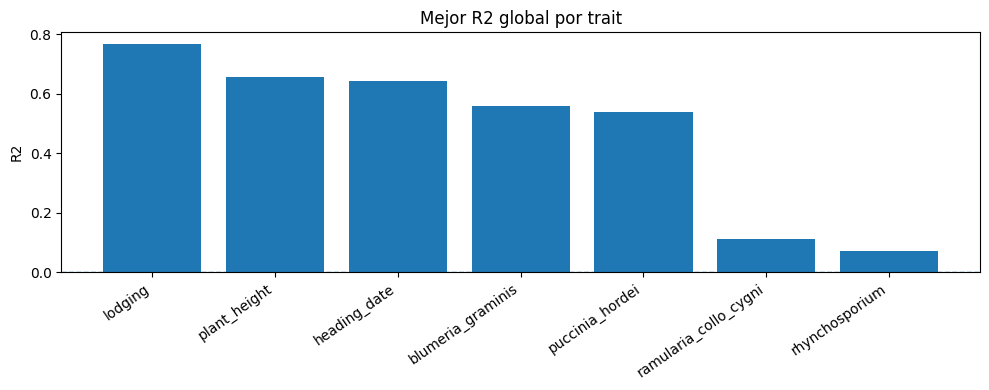

In [ ]:
plot_df = best_global_df.sort_values("r2", ascending=False)

plt.figure(figsize=(10, 4))
plt.bar(plot_df["trait"], plot_df["r2"])
plt.axhline(0, linestyle="--", linewidth=1)
plt.xticks(rotation=35, ha="right")
plt.ylabel("R2")
plt.title("Mejor R2 global por trait")
plt.tight_layout()
plt.show()


In [16]:
from pathlib import Path
import pandas as pd
from IPython.display import display

# ---------------------------------------------------------
# 1) Resolver carpeta de salida
# ---------------------------------------------------------
OUT = Path(OUTPUT_DIR) if "OUTPUT_DIR" in globals() else Path("results/snp_blocks_notebook_nested5x3")
OUT.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# 2) Intentar construir master desde DataFrame en memoria
# ---------------------------------------------------------
master_df = None
candidate_names = [
    "resultados_df", "all_results_df", "results_df", "final_results_df", "master_df"
]

for name in candidate_names:
    obj = globals().get(name, None)
    if isinstance(obj, pd.DataFrame) and not obj.empty and {"trait", "model"}.issubset(obj.columns):
        master_df = obj.copy()
        print(f"[OK] Usando DataFrame en memoria: {name} ({len(master_df)} filas)")
        break

# ---------------------------------------------------------
# 3) Fallback: reconstruir desde CSV por modelo
# ---------------------------------------------------------
if master_df is None:
    files = sorted(OUT.glob("*_results.csv"))
    files = [f for f in files if f.name not in {"best_global_results.csv", "all_results.csv"}]

    frames = []
    for f in files:
        df = pd.read_csv(f)
        if {"trait", "model"}.issubset(df.columns):
            df["source_file"] = f.name
            frames.append(df)

    if not frames:
        raise RuntimeError("No se encontró DataFrame en memoria ni CSV por modelo para construir el master.")

    master_df = pd.concat(frames, ignore_index=True)
    print(f"[OK] Master reconstruido desde {len(frames)} archivos CSV ({len(master_df)} filas)")

# ---------------------------------------------------------
# 4) Limpieza ligera + orden
# ---------------------------------------------------------
if "model" in master_df.columns:
    master_df["model"] = master_df["model"].astype(str).str.strip().str.lower()

if "trait" in master_df.columns:
    master_df["trait"] = master_df["trait"].astype(str).str.strip().str.lower()

sort_cols = [c for c in ["model", "trait"] if c in master_df.columns]
if sort_cols:
    master_df = master_df.sort_values(sort_cols).reset_index(drop=True)

# Reordenar columnas (si existen)
preferred_cols = [
    "model", "trait", "pearson_r", "pearson_p", "r2", "rmse", "mae",
    "params", "n_individuos", "n_snps", "n_configs_model",
    "fits_por_config", "fits_ejecutados_config", "fit_time_s", "cv",
    "source_file"
]
existing_pref = [c for c in preferred_cols if c in master_df.columns]
other_cols = [c for c in master_df.columns if c not in existing_pref]
master_df = master_df[existing_pref + other_cols]

# ---------------------------------------------------------
# 5) Exportar MASTER (CSV + Excel)
# ---------------------------------------------------------
csv_out = OUT / "snp_direct_nested5x3_master_results.csv"
xlsx_out = OUT / "snp_direct_nested5x3_master_results.xlsx"

master_df.to_csv(csv_out, index=False)

with pd.ExcelWriter(xlsx_out) as writer:
    master_df.to_excel(writer, sheet_name="master_results", index=False)
    if "best_global_df" in globals() and isinstance(best_global_df, pd.DataFrame) and not best_global_df.empty:
        best_global_df.to_excel(writer, sheet_name="best_global", index=False)

print(f"[GUARDADO] {csv_out}")
print(f"[GUARDADO] {xlsx_out}")
print(f"[INFO] Filas: {len(master_df)} | Modelos: {master_df['model'].nunique() if 'model' in master_df.columns else 'NA'} | Traits: {master_df['trait'].nunique() if 'trait' in master_df.columns else 'NA'}")

display(master_df.head(15))


[OK] Master reconstruido desde 3 archivos CSV (21 filas)
[GUARDADO] results\snp_blocks_notebook_nested5x3\snp_direct_nested5x3_master_results.csv
[GUARDADO] results\snp_blocks_notebook_nested5x3\snp_direct_nested5x3_master_results.xlsx
[INFO] Filas: 21 | Modelos: 3 | Traits: 7


,model,trait,pearson_r,pearson_p,r2,rmse,params,n_individuos,n_snps,n_configs_model,fits_por_config,fits_ejecutados_config,fit_time_s,cv,source_file
0,elasticnet,blumeria_graminis,0.744957,5.242560e-197,0.549060,0.781613,"alpha=1.0, l1_ratio=0.05",1110,61139,16,15,245,1699.813389,"NestedKFold_manual(outer=5, inner=3, random_st...",elasticnet_results.csv
1,elasticnet,heading_date,0.801552,1.000554e-249,0.642298,19.005048,"alpha=1.0, l1_ratio=0.1",1110,61139,16,15,245,2712.653376,"NestedKFold_manual(outer=5, inner=3, random_st...",elasticnet_results.csv
2,elasticnet,lodging,0.874784,0.000000e+00,0.764419,0.768276,"alpha=0.1, l1_ratio=0.05",1110,61139,16,15,245,1809.648774,"NestedKFold_manual(outer=5, inner=3, random_st...",elasticnet_results.csv
3,elasticnet,plant_height,0.810845,4.934020e-260,0.656123,8.403867,"alpha=0.01, l1_ratio=0.05",1110,61139,16,15,245,2303.976361,"NestedKFold_manual(outer=5, inner=3, random_st...",elasticnet_results.csv
4,elasticnet,puccinia_hordei,0.712740,7.517172e-173,0.502425,0.838456,"alpha=1.0, l1_ratio=0.05",1110,61139,16,15,245,1720.214344,"NestedKFold_manual(outer=5, inner=3, random_st...",elasticnet_results.csv
5,elasticnet,ramularia_collo_cygni,0.337916,4.734712e-31,0.114078,1.055126,"alpha=1.0, l1_ratio=0.05",1110,61139,16,15,245,1840.737393,"NestedKFold_manual(outer=5, inner=3, random_st...",elasticnet_results.csv
6,elasticnet,rhynchosporium,0.171765,8.460075e-09,0.023798,0.904316,"alpha=1.0, l1_ratio=0.1",1110,61139,16,15,245,1825.227251,"NestedKFold_manual(outer=5, inner=3, random_st...",elasticnet_results.csv
7,ridge,blumeria_graminis,0.748807,3.873785e-200,0.560161,0.771932,alpha=1000.0,1110,61139,6,15,95,290.088198,"NestedKFold_manual(outer=5, inner=3, random_st...",ridge_results.csv
8,ridge,heading_date,0.795237,4.965799e-243,0.631102,19.300173,alpha=0.1,1110,61139,6,15,95,274.001837,"NestedKFold_manual(outer=5, inner=3, random_st...",ridge_results.csv
9,ridge,lodging,0.877441,0.000000e+00,0.768754,0.761174,alpha=0.1,1110,61139,6,15,95,413.525955,"NestedKFold_manual(outer=5, inner=3, random_st...",ridge_results.csv
